# **Análise de dados da ClínicaCare**
## Analisar dados da clínica utilizando Python, construir visualizações e treinar um modelo de Machine Learning para prever comportamento de pacientes.

Bibliotecas carregadas com sucesso!
Dataset carregado!
NumPy - Média de dias de antecedência: 8.70
NumPy - Desvio Padrão de dias de antecedência: 8.96


/tmp/ipykernel_1692/1704885884.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(taxa_esp.index, rotation=45, ha='right')


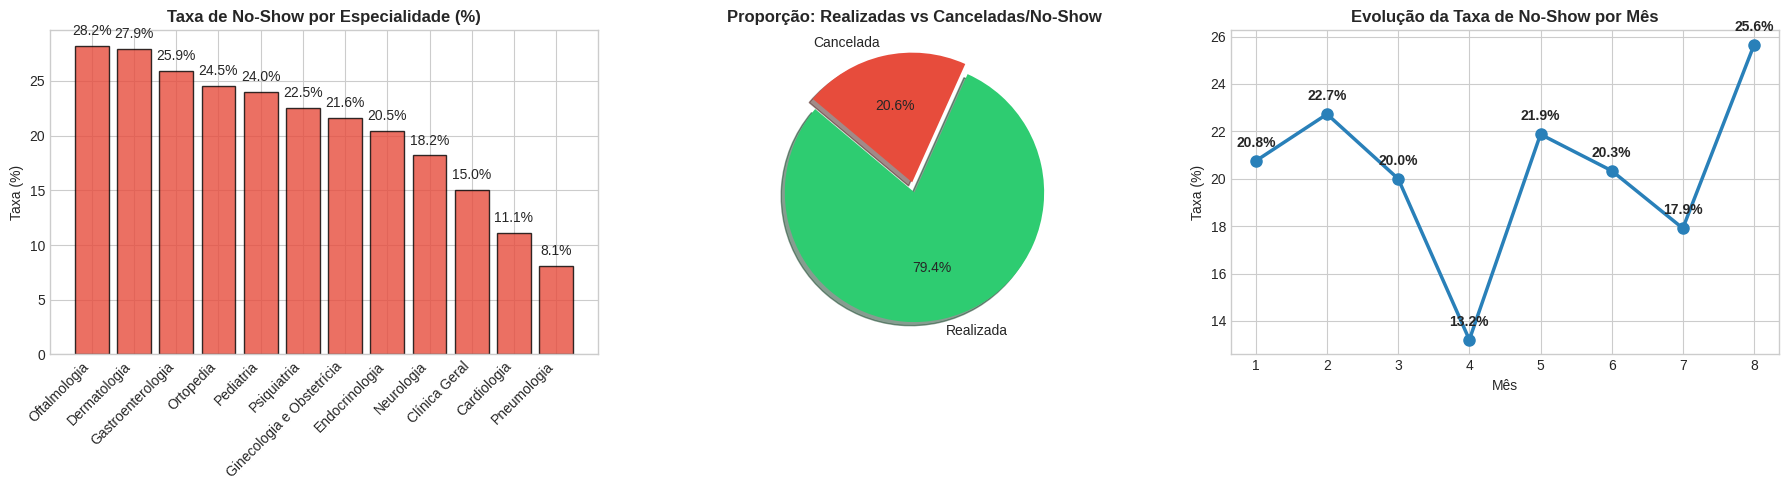

In [40]:
# Importando bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

print("Bibliotecas carregadas com sucesso!")

# Carregar dataset
df = pd.read_csv('dados_limpos.csv')
print("Dataset carregado!")

# Análise NumPy
dias_ant = df['dias_antecedencia_agendamento'].to_numpy()
media_ant = np.mean(dias_ant)
std_ant = np.std(dias_ant)
print(f"NumPy - Média de dias de antecedência: {media_ant:.2f}")
print(f"NumPy - Desvio Padrão de dias de antecedência: {std_ant:.2f}")

# Tratamento de dados
df_model = df[df['no_show'].notna()].copy()
df_model['no_show'] = df_model['no_show'].astype(int)

# Visualizações
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico de barras: taxa de no-show por especialidade
taxa_esp = df_model.groupby('especialidade_principal')['no_show'].mean().sort_values(ascending=False) * 100
axes[0].bar(taxa_esp.index, taxa_esp.values, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0].set_title('Taxa de No-Show por Especialidade (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Taxa (%)')
axes[0].set_xticklabels(taxa_esp.index, rotation=45, ha='right')
for i, v in enumerate(taxa_esp.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

# Gráfico de pizza: Proporção de consultas realizadas x faltadas
counts = df_model['status_consulta'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=140, explode=(0, 0.08), shadow=True)
axes[1].set_title('Proporção: Realizadas vs Canceladas/No-Show', fontsize=12, fontweight='bold')

# Gráfico de linha: Evolução de no-shows ao longo dos meses
mes_taxa = df_model.groupby('mes')['no_show'].agg(['count', 'sum'])
mes_taxa['taxa'] = (mes_taxa['sum'] / mes_taxa['count']) * 100
axes[2].plot(mes_taxa.index, mes_taxa['taxa'], marker='o', color='#2980b9', linewidth=2.5, markersize=8)
axes[2].set_title('Evolução da Taxa de No-Show por Mês', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('Taxa (%)')
axes[2].set_xticks(mes_taxa.index)
for x, y in zip(mes_taxa.index, mes_taxa['taxa']):
    axes[2].annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

# Resultado dos gráficos
plt.tight_layout()
plt.show()
plt.close()

### **Treinamento de modelo usando Regressão Logística**

In [41]:
# Classificando features
features_num = ['idade_paciente', 'medico_tempo_casa_dias', 'dias_antecedencia_agendamento',
                'hora_consulta', 'mes', 'valor_cobrado', 'tempo_medio_consulta_min',
                'consultas_anteriores_paciente', 'no_shows_anteriores_paciente']

features_cat = ['genero_paciente', 'especialidade_principal', 'dia_semana', 'periodo_dia']

X = df_model[features_num + features_cat]
y = df_model['no_show']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
    ]
)

# Regressão logística
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== Regressão Logística ===")
print("Acurácia:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

=== Regressão Logística ===
Acurácia: 0.6693548387096774
ROC AUC: 0.6393249607535322

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.72      0.78        98
           1       0.31      0.46      0.37        26

    accuracy                           0.67       124
   macro avg       0.57      0.59      0.57       124
weighted avg       0.72      0.67      0.69       124



### **Treinamento de modelo usando Árvore de Decisão**
Vamos testar um algoritmo alternativo para ver se conseguimos uma performance melhor, especialmente na identificação de no-shows (Classe 1).

In [42]:
# Árvore de Decisão
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)
y_proba_dt = dt_pipeline.predict_proba(X_test)[:, 1]

print("=== Árvore de Decisão ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_dt):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

=== Árvore de Decisão ===
Acurácia: 0.6452
ROC AUC: 0.5801

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.71      0.76        98
           1       0.26      0.38      0.31        26

    accuracy                           0.65       124
   macro avg       0.54      0.55      0.54       124
weighted avg       0.70      0.65      0.67       124



### **Comparação de Modelos**
Podemos observar qual modelo teve um melhor 'Recall' para a classe 1, que representa os pacientes que faltam.

,Modelo,Recall (Classe 1),Acurácia,ROC AUC
0,Regressão Logística,0.461538,0.669355,0.639325
1,Árvore de Decisão,0.384615,0.645161,0.580063


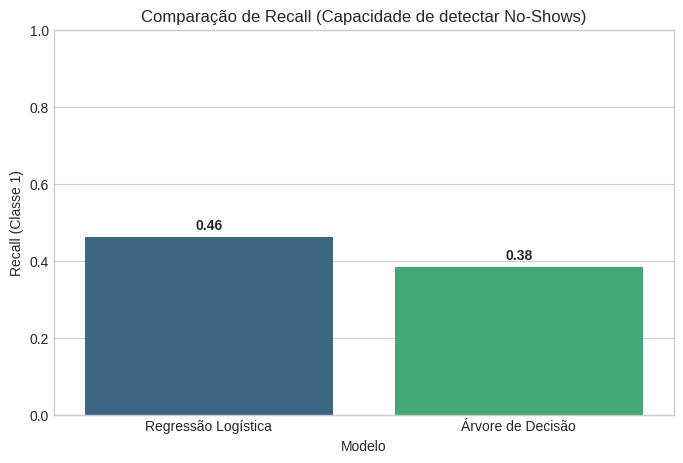

In [43]:
from sklearn.metrics import recall_score

# Calculando recall para a classe 1 (No-Show)
recall_lr = recall_score(y_test, y_pred_lr)
recall_dt = recall_score(y_test, y_pred_dt)

# Criando dataframe de comparação
comp_df = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore de Decisão'],
    'Recall (Classe 1)': [recall_lr, recall_dt],
    'Acurácia': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt)],
    'ROC AUC': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_dt)]
})

display(comp_df)

# Visualização da comparação de Recall (Corrigido para evitar FutureWarning)
plt.figure(figsize=(8, 5))
sns.barplot(x='Modelo', y='Recall (Classe 1)', data=comp_df, hue='Modelo', palette='viridis', legend=False)
plt.title('Comparação de Recall (Capacidade de detectar No-Shows)')
plt.ylim(0, 1)
for i, val in enumerate(comp_df['Recall (Classe 1)']):
    plt.text(i, val + 0.02, f'{val:.2f}', ha='center', fontweight='bold')
plt.show()

Com base nos resultados:
- A **Regressão Logística** possui um Recall maior, sendo melhor para capturar o maior número possível de faltas.
- A **Árvore de Decisão** costuma ser mais explicável, mas aqui buscamos maximizar a identificação de risco.

### **Aplicação de Score de Risco nas consultas agendadas**

In [44]:
df_agendadas = df[df['no_show'].isna()].copy()

if len(df_agendadas) > 0:
    probas_futuras = lr_pipeline.predict_proba(df_agendadas[features_num + features_cat])[:, 1]
    df_agendadas['probabilidade_no_show'] = np.round(probas_futuras, 3)
    df_agendadas['classificacao_risco'] = np.where(df_agendadas['probabilidade_no_show'] >= 0.5, 'Alto Risco', 'Baixo Risco')
    print("Contagem por Risco (Agendadas):")
    print(df_agendadas['classificacao_risco'].value_counts())
    print("\nTabela contendo previsões:")
    print(df_agendadas[['especialidade_principal', 'dias_antecedencia_agendamento', 'probabilidade_no_show', 'classificacao_risco']])

Contagem por Risco (Agendadas):
classificacao_risco
Baixo Risco    17
Alto Risco     10
Name: count, dtype: int64

Tabela contendo previsões:
       especialidade_principal  dias_antecedencia_agendamento  \
495                Cardiologia                              5   
496                Cardiologia                              5   
497               Dermatologia                              2   
498                Pneumologia                             18   
499              Clínica Geral                             10   
500              Clínica Geral                              0   
501                  Pediatria                             11   
502                 Neurologia                             13   
503                Cardiologia                              1   
504               Dermatologia                              2   
505              Clínica Geral                              3   
506                Psiquiatria                              1   
507          